In [287]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder,OneHotEncoder,OrdinalEncoder
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV,cross_validate
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix,roc_auc_score, roc_curve,ConfusionMatrixDisplay,silhouette_score
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.tree import DecisionTreeClassifier
from datetime import datetime
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.cluster import KMeans , DBSCAN
from itertools import combinations
from sklearn.decomposition import PCA

In [288]:
df=pd.read_csv('Country-data.csv')

In [289]:
df.sample(5)

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
22,Brazil,19.8,10.7,9.01,11.8,14500,8.410,74.2,1.80,11200
91,Luxembourg,2.8,175.0,7.77,142.0,91700,3.620,81.3,1.63,105000
86,Lebanon,10.3,35.8,7.03,60.2,16300,0.238,79.8,1.61,8860
97,Mali,137.0,22.8,4.98,35.1,1870,4.370,59.5,6.55,708
88,Liberia,89.3,19.1,11.80,92.6,700,5.470,60.8,5.02,327


In [290]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


In [291]:
num=df.select_dtypes(exclude='object')
cat=df.select_dtypes(include='object')

In [292]:
cat.describe()

,country
count,167
unique,167
top,Afghanistan
freq,1


In [293]:
num.describe()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000
mean,38.270060,41.108976,6.815689,46.890215,17144.688623,7.781832,70.555689,2.947964,12964.155689
std,40.328931,27.412010,2.746837,24.209589,19278.067698,10.570704,8.893172,1.513848,18328.704809
min,2.600000,0.109000,1.810000,0.065900,609.000000,-4.210000,32.100000,1.150000,231.000000
25%,8.250000,23.800000,4.920000,30.200000,3355.000000,1.810000,65.300000,1.795000,1330.000000
50%,19.300000,35.000000,6.320000,43.300000,9960.000000,5.390000,73.100000,2.410000,4660.000000
75%,62.100000,51.350000,8.600000,58.750000,22800.000000,10.750000,76.800000,3.880000,14050.000000
max,208.000000,200.000000,17.900000,174.000000,125000.000000,104.000000,82.800000,7.490000,105000.000000


In [294]:
df.shape

(167, 10)

In [295]:
df.isnull().sum().sort_values(ascending=False)

country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64

In [296]:
df.drop(columns=['country'],inplace=True)
# label=LabelEncoder()
# df['country']=label.fit_transform(df['country'])

In [297]:
from sklearn.preprocessing import RobustScaler
scale=MinMaxScaler()
df_scaled = scale.fit_transform(df)
df = pd.DataFrame(df_scaled, columns=df.columns)

In [ ]:
from sklearn.ensemble import IsolationForest

iso = IsolationForest(contamination=0.05, random_state=42) 
yhat = iso.fit_predict(df)
mask = yhat != -1
df_no_outliers = df[mask]

print("besfore:", df.shape)
print("after:", df_no_outliers.shape)


besfore: (167, 9)
after: (158, 9)


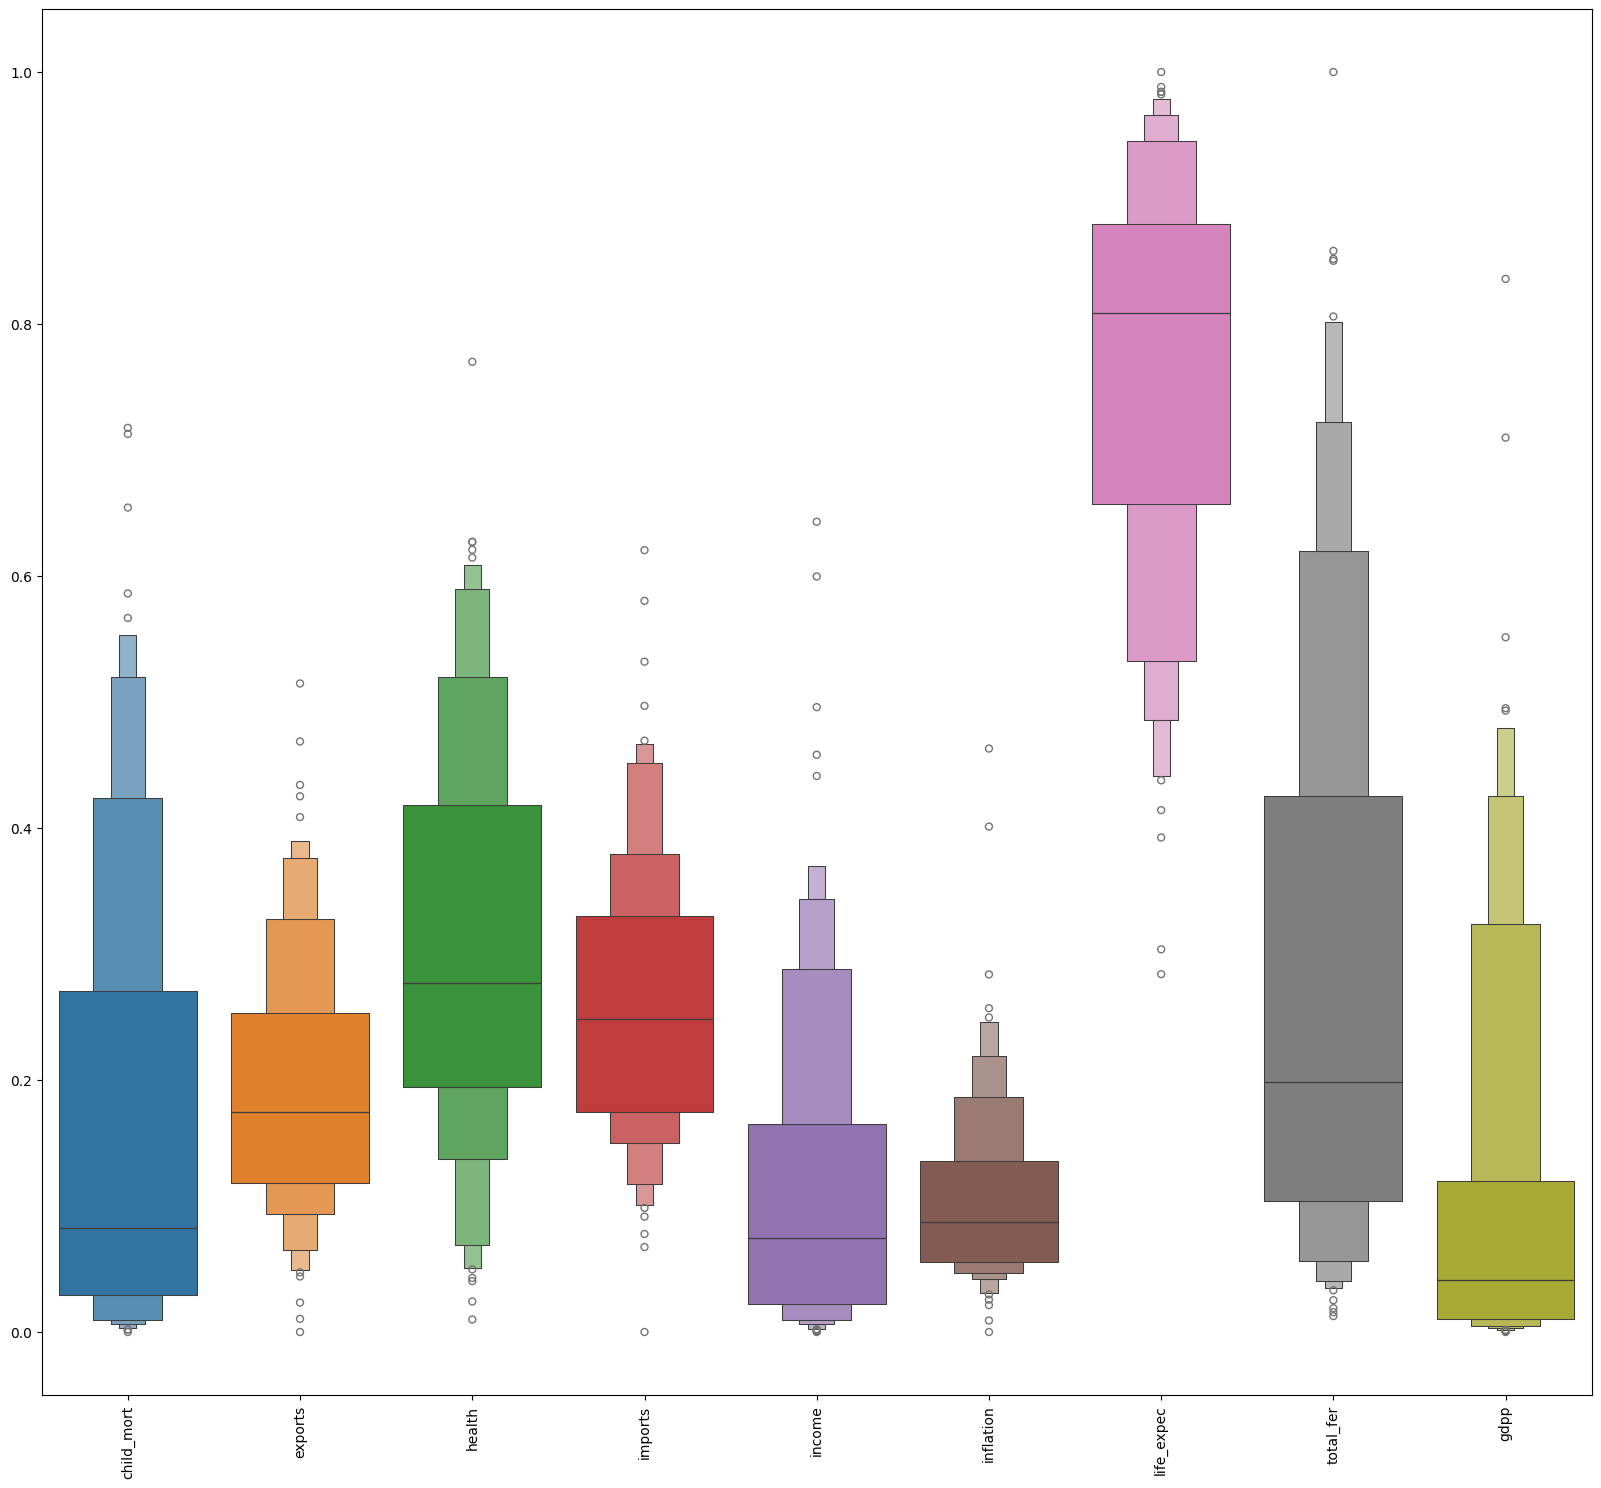

In [299]:
plt.figure(figsize=(20,18))
sns.boxenplot(df_no_outliers)
plt.xticks(rotation=90)
plt.show()

In [300]:
#try pca on all data
pca=PCA(n_components=2)
X=pca.fit_transform(df)

In [301]:
X=pd.DataFrame(X,columns=['C1','C2'])

In [302]:
score=[]
elbow=[]
for k in range(2,11):
    model=KMeans(n_clusters=k,random_state=42)
    y_pre=model.fit_predict(X)
    score.append(silhouette_score(X,y_pre))
    elbow.append(model.inertia_)

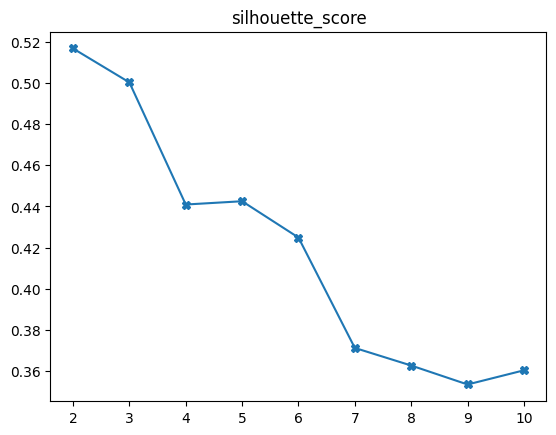

In [303]:
plt.plot(range(2,11),score,marker='X')
plt.title('silhouette_score')
plt.show()

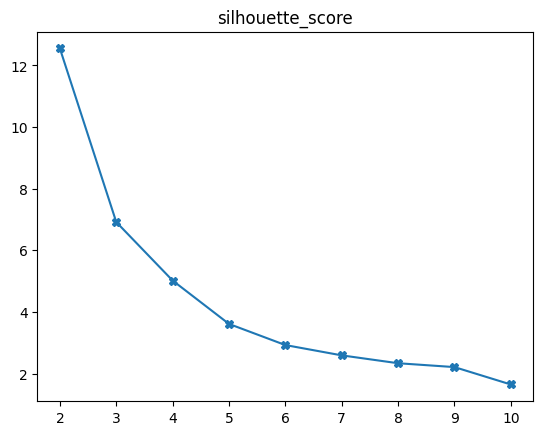

In [304]:
plt.plot(range(2,11),elbow,marker='X')
plt.title('silhouette_score')
plt.show()

In [305]:
model=KMeans(n_clusters=2,random_state=42)
y_pred=model.fit_predict(X)

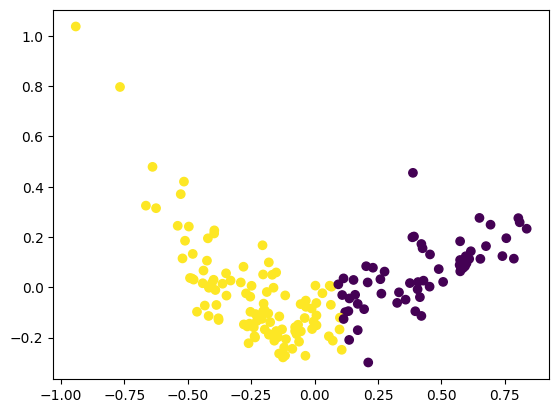

In [306]:
plt.scatter(X['C1'],X['C2'],c=y_pred)

In [307]:
silhouette_score(X,y_pred)

np.float64(0.5167744556201839)

In [308]:
#try best 2 features have  best variance
variances=df.var().sort_values(ascending=False)
print(variances)
top_features = variances.head(10).index
print(top_features)

total_fer     0.057015
child_mort    0.038551
life_expec    0.030768
gdpp          0.030605
health        0.029144
income        0.024019
imports       0.019373
exports       0.018806
inflation     0.009543
dtype: float64
Index(['total_fer', 'child_mort', 'life_expec', 'gdpp', 'health', 'income',
       'imports', 'exports', 'inflation'],
      dtype='object')


In [309]:
score=[]
elbow=[]
for k in range(2,11):
    mod=KMeans(n_clusters=k,random_state=42)
    y_pred=mod.fit_predict(df_no_outliers[['gdpp','inflation']])
    score.append(silhouette_score(df_no_outliers[['gdpp','inflation']],y_pred))
    elbow.append(mod.inertia_)

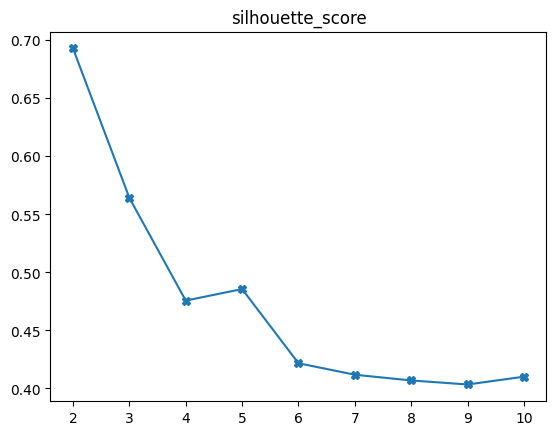

In [310]:
plt.plot(range(2,11),score,marker='X')
plt.title('silhouette_score')
plt.show()

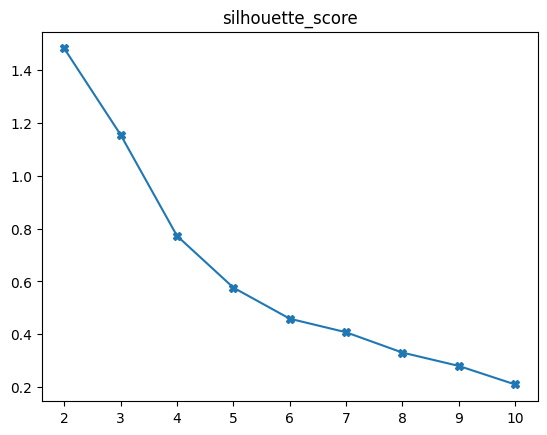

In [311]:
plt.plot(range(2,11),elbow,marker='X')
plt.title('silhouette_score')
plt.show()

In [312]:
mod=KMeans(n_clusters=2,random_state=42)
y_pred=mod.fit_predict(df_no_outliers[['gdpp','inflation']])

In [313]:
silhouette_score(df_no_outliers[['gdpp','inflation']],y_pred)

np.float64(0.6929209756115527)

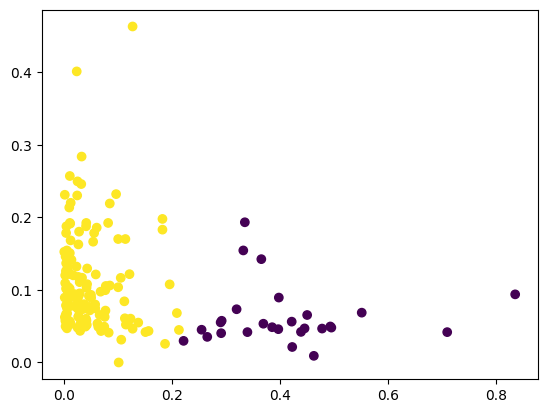

In [314]:
plt.scatter(df_no_outliers['gdpp'],df_no_outliers['inflation'],c=y_pred)
plt.show()

In [315]:
# try all data 
df=pd.read_csv('Country-data.csv')

In [316]:
num=df.select_dtypes(exclude='object').columns
cat=df.select_dtypes(include='object')

In [317]:
scale=MinMaxScaler()
df_scaled=scale.fit_transform(df[num])
df_num=pd.DataFrame(df_scaled,columns=num)

In [318]:
label=LabelEncoder()
df['country']=label.fit_transform(df['country'])

In [320]:
df_new=pd.concat([df_num, df[['country']]], axis=1)

In [321]:
score=[]
elbow=[]
for k in range(2,11):
    mod=KMeans(n_clusters=k,random_state=42)
    y_pred=mod.fit_predict(df_new)
    score.append(silhouette_score(df_new,y_pred))
    elbow.append(mod.inertia_)

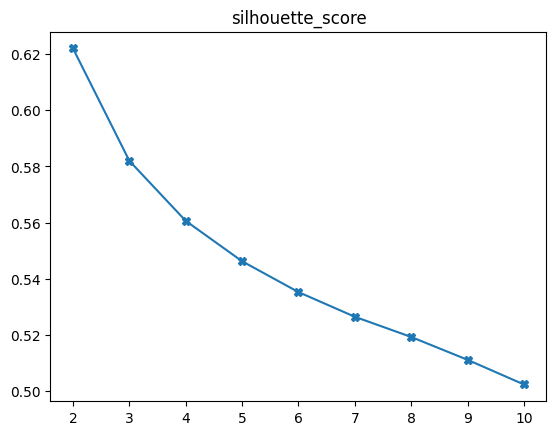

In [322]:
plt.plot(range(2,11),score,marker='X')
plt.title('silhouette_score')
plt.show()

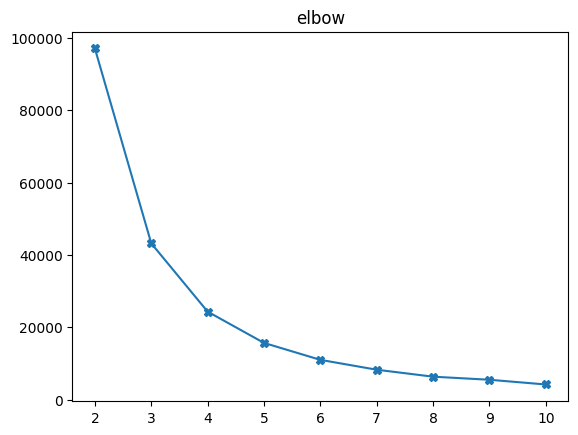

In [323]:
plt.plot(range(2,11),elbow,marker='X')
plt.title('elbow')
plt.show()

In [324]:
score = -1
best_k = -1
for i in range(2,11):
    km = KMeans(n_clusters=i)
    y_pred = km.fit_predict(df_new)
    temp = silhouette_score(df_new,y_pred)
    if temp >= score:
        score = temp
        best_k = i

In [325]:
score*100

np.float64(62.1972985104122)

In [326]:
km=KMeans(n_clusters=2,random_state=42)
y_pred=km.fit_predict(df_new)

In [327]:
pc=PCA(n_components=2)
data=pc.fit_transform(df_new)
data=pd.DataFrame(data,columns=['c1','c2'])

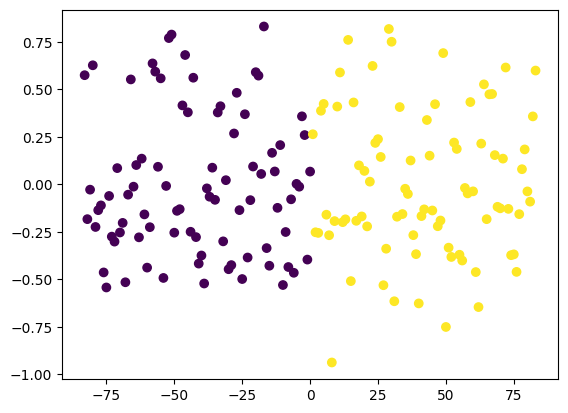

In [328]:
plt.scatter(data['c1'],data['c2'],c=y_pred)
plt.show()